# Load Empirical Data, Extract Features, and Compute Predictions

This notebook follows the same empirical LFP workflow used in `examples/LFP_developing_brain/LFP_developing_brain.py`:
- load empirical LFP recordings,
- extract `catch22` features,
- compute predictions with pre-trained ML assets.

In this tutorial, predictions are computed directly from the provided local `model` and `scaler` files.

## Requirements

To run this notebook, install:
- `ncpi`
- `pycatch22`
- `scikit-learn`
- `matplotlib`

Expected local resources:
- Empirical data folder: `/home/pablomc/Downloads/empirical_data/LFP/`
- Model file: `/home/pablomc/Downloads/ML_models/MLP/catch22/model`
- Scaler file: `/home/pablomc/Downloads/ML_models/MLP/catch22/scaler`

### 1) Set up imports and fixed local paths

This tutorial uses the exact empirical and model paths provided above.

In [1]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import ncpi
from ncpi.EphysDatasetParser import EphysDatasetParser, ParseConfig, CanonicalFields

EMPIRICAL_PATH = Path("/home/pablomc/Downloads/empirical_data/LFP/")
MODEL_PATH = Path("/home/pablomc/Downloads/ML_models/MLP/catch22/")
MODEL_FILE = MODEL_PATH / "model"
SCALER_FILE = MODEL_PATH / "scaler"

print("Empirical path:", EMPIRICAL_PATH)
print("Model file:", MODEL_FILE)
print("Scaler file:", SCALER_FILE)

if not EMPIRICAL_PATH.exists():
    raise FileNotFoundError(f"Empirical path not found: {EMPIRICAL_PATH}")
if not MODEL_FILE.exists():
    raise FileNotFoundError(f"Model file not found: {MODEL_FILE}")
if not SCALER_FILE.exists():
    raise FileNotFoundError(f"Scaler file not found: {SCALER_FILE}")


Empirical path: /home/pablomc/Downloads/empirical_data/LFP
Model file: /home/pablomc/Downloads/ML_models/MLP/catch22/model
Scaler file: /home/pablomc/Downloads/ML_models/MLP/catch22/scaler


### 2) Load and parse empirical LFP recordings

Each file is parsed to canonical schema with:
- 5-second non-overlapping epochs,
- channel aggregation by sum,
- metadata fields (`subject_id`, `group`, `species`, `recording_type`).

In [2]:
def load_empirical_lfp_data(empirical_path: Path) -> pd.DataFrame:
    files = sorted(empirical_path.glob("*.mat"))
    if not files:
        raise FileNotFoundError(f"No .mat files found in: {empirical_path}")

    all_rows = []

    for subject_id, file_path in enumerate(files):
        print(f"\rProgress: {subject_id + 1}/{len(files)} files loaded", end="", flush=True)

        config = ParseConfig(
            fields=CanonicalFields(
                data=lambda d: d["LFP"].LFP,
                fs=lambda d: float(np.asarray(d["LFP"].fs).squeeze()),
                ch_names=lambda d: [f"ch{i}" for i in range(d["LFP"].LFP.shape[0])],
                metadata={
                    "subject_id": subject_id,
                    "group": lambda d: int(np.asarray(d["LFP"].age).squeeze()),
                    "species": "mouse",
                    "recording_type": "LFP",
                },
            ),
            epoch_length_s=5.0,
            epoch_step_s=5.0,
            aggregate_over=("sensor",),
            aggregate_method="sum",
        )

        parser = EphysDatasetParser(config)
        df_file = parser.parse(file_path)
        all_rows.append(df_file)

    print(f"\nLoaded files: {len(all_rows)}")
    return pd.concat(all_rows, ignore_index=True)


emp_data = load_empirical_lfp_data(EMPIRICAL_PATH)
print("Empirical dataframe shape:", emp_data.shape)
emp_data.head()


Progress: 86/86 files loaded
Loaded files: 86
Empirical dataframe shape: (72512, 16)


,subject_id,species,group,condition,epoch,sensor,recording_type,fs,data,t0,t1,data_domain,f0,f1,spectral_kind,source_file
0,0,mouse,12,NaN,0,aggregate,<scipy.io.matlab._mio5_params.mat_struct objec...,100.0,"[106457.98602902623, -149539.74712124988, -111...",0.0,4.99,time,NaN,NaN,NaN,/home/pablomc/Downloads/empirical_data/LFP/1.mat
1,0,mouse,12,NaN,1,aggregate,<scipy.io.matlab._mio5_params.mat_struct objec...,100.0,"[17046.739847328776, 17337.584541334687, 17325...",5.0,9.99,time,NaN,NaN,NaN,/home/pablomc/Downloads/empirical_data/LFP/1.mat
2,0,mouse,12,NaN,2,aggregate,<scipy.io.matlab._mio5_params.mat_struct objec...,100.0,"[-1650.4351428274397, -1521.4494185280719, -11...",10.0,14.99,time,NaN,NaN,NaN,/home/pablomc/Downloads/empirical_data/LFP/1.mat
3,0,mouse,12,NaN,3,aggregate,<scipy.io.matlab._mio5_params.mat_struct objec...,100.0,"[999.3953207405618, 1053.0786939545467, 1281.7...",15.0,19.99,time,NaN,NaN,NaN,/home/pablomc/Downloads/empirical_data/LFP/1.mat
4,0,mouse,12,NaN,4,aggregate,<scipy.io.matlab._mio5_params.mat_struct objec...,100.0,"[203.7253504844328, 153.98154989454363, 156.40...",20.0,24.99,time,NaN,NaN,NaN,/home/pablomc/Downloads/empirical_data/LFP/1.mat


### 3) Extract `catch22` features from empirical epochs

In [3]:
feature_engine = ncpi.Features(method="catch22", params={"normalize": True})

emp_data = emp_data.copy()
emp_data["Features"] = feature_engine.compute_features(emp_data["data"].to_list())

X_emp = np.vstack([np.asarray(f, dtype=float) for f in emp_data["Features"].to_list()])
print("Empirical feature matrix shape:", X_emp.shape)


Computing catch22 features: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 72512/72512 [00:13<00:00, 5366.67it/s]


Empirical feature matrix shape: (72512, 22)


### 4) Load model/scaler and compute predictions

This step uses the provided local files directly.

If the loaded model is an ensemble list, predictions are averaged across ensemble members.

In [4]:
with MODEL_FILE.open("rb") as f:
    model = pickle.load(f)

with SCALER_FILE.open("rb") as f:
    scaler = pickle.load(f)


def predict_with_model(X: np.ndarray, scaler_obj, model_obj) -> np.ndarray:
    X_scaled = scaler_obj.transform(X)

    if isinstance(model_obj, list):
        all_preds = [np.asarray(m.predict(X_scaled), dtype=float) for m in model_obj]
        return np.mean(np.stack(all_preds, axis=0), axis=0)

    return np.asarray(model_obj.predict(X_scaled), dtype=float)


pred_raw = predict_with_model(X_emp, scaler, model)
pred_raw = np.asarray(pred_raw, dtype=float)
if pred_raw.ndim == 1:
    pred_raw = pred_raw.reshape(-1, 1)

print("Raw prediction shape:", pred_raw.shape)

if pred_raw.shape[1] >= 7:
    pred_ei = (pred_raw[:, 0] / pred_raw[:, 2]) / (pred_raw[:, 1] / pred_raw[:, 3])
    pred_tau_exc = pred_raw[:, 4]
    pred_tau_inh = pred_raw[:, 5]
    pred_j_ext = pred_raw[:, 6]
elif pred_raw.shape[1] == 4:
    pred_ei = pred_raw[:, 0]
    pred_tau_exc = pred_raw[:, 1]
    pred_tau_inh = pred_raw[:, 2]
    pred_j_ext = pred_raw[:, 3]
else:
    raise ValueError(
        f"Unsupported prediction dimensionality: {pred_raw.shape[1]}. Expected 4 or >=7 outputs."
    )

predictions_df = emp_data[["subject_id", "group"]].copy()
predictions_df["E_I"] = pred_ei
predictions_df["tau_exc"] = pred_tau_exc
predictions_df["tau_inh"] = pred_tau_inh
predictions_df["J_ext"] = pred_j_ext

predictions_df[["E_I", "tau_exc", "tau_inh", "J_ext"]].describe()


/home/pablomc/anaconda3/envs/ncpi-env/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MLPRegressor from version 1.3.2 when using version 1.5.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/pablomc/anaconda3/envs/ncpi-env/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.3.2 when using version 1.5.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Raw prediction shape: (72512, 7)


,E_I,tau_exc,tau_inh,J_ext
count,72512.000000,72512.000000,72512.000000,72512.000000
mean,1.936655,0.974795,4.248541,26.193148
std,73.363238,0.325364,1.951607,12.951049
min,-3983.937370,-9.541862,-33.963710,-85.565175
25%,0.673533,0.788808,3.116595,19.035746
50%,1.205469,0.967518,4.135929,28.194428
75%,2.122702,1.158769,5.293383,35.594296
max,17261.298469,2.555367,38.612775,126.600647


### 5) Plot boxplots of predicted parameters

For each predicted parameter, values are plotted as a function of age (`group`).

Statistical annotations use **Cohen's d** (control age vs other ages), shown as stars based on effect-size magnitude.

Panels are shown for:
- predicted `E/I`,
- predicted `tau_exc`,
- predicted `tau_inh`,
- predicted `J_ext`.

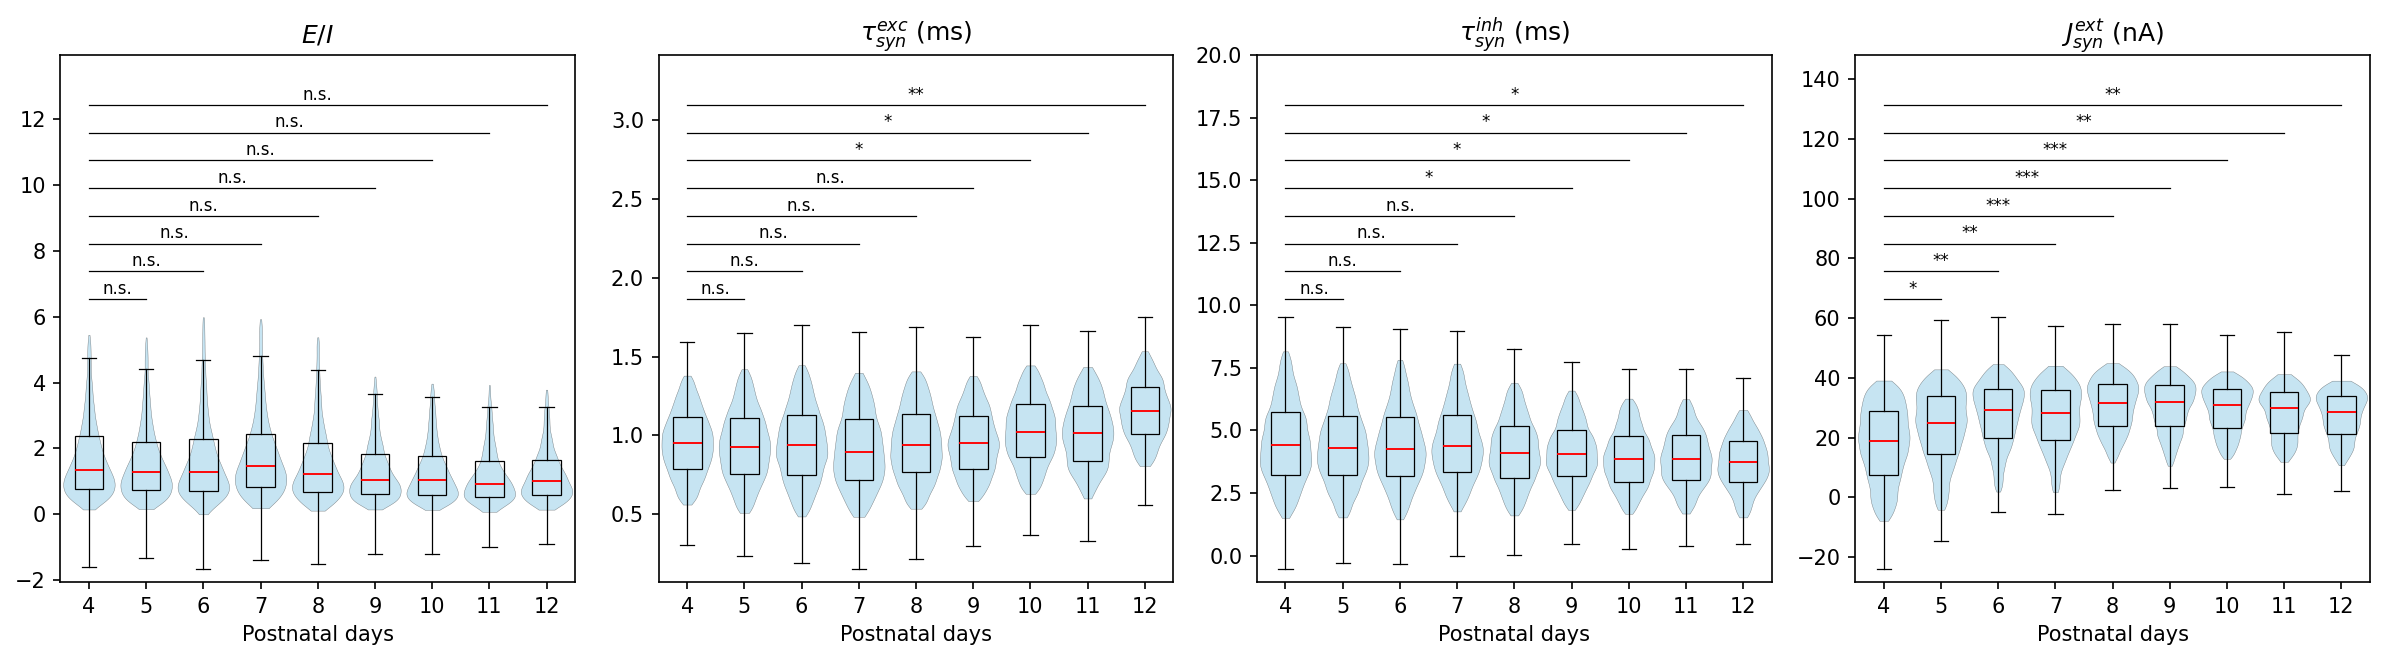

In [5]:
plot_columns = [
    ("E_I", r"$E/I$"),
    ("tau_exc", r"$\tau_{syn}^{exc}$ (ms)"),
    ("tau_inh", r"$\tau_{syn}^{inh}$ (ms)"),
    ("J_ext", r"$J_{syn}^{ext}$ (nA)"),
]


def cohend_to_stars(d_value: float) -> str:
    """Map |Cohen's d| to significance-style stars."""
    ad = abs(float(d_value))
    if ad < 0.2:
        return "n.s."
    if ad < 0.5:
        return "*"
    if ad < 0.8:
        return "**"
    if ad < 1.2:
        return "***"
    return "****"


predictions_df = predictions_df.copy()
predictions_df["group"] = predictions_df["group"].astype(int)
predictions_df = predictions_df[predictions_df["group"] >= 4].copy()

if predictions_df.empty:
    raise ValueError("No predictions available for ages >= 4.")

ages_sorted = np.array(sorted(predictions_df["group"].unique()), dtype=int)
control_group = 4
if control_group not in ages_sorted:
    raise ValueError("Control group age=4 is not present in the filtered data.")

groups_to_annotate = [int(a) for a in ages_sorted if int(a) != control_group]

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5), dpi=150)

for ax, (col, title) in zip(axes, plot_columns):
    # Boxplots as a function of age
    for age in ages_sorted:
        data_plot = predictions_df.loc[predictions_df["group"] == age, col].dropna().to_numpy(dtype=float)
        if data_plot.size == 0:
            continue

        # Match the LFP_predictions style: clip for violin and overlay boxplots
        q1, q3 = np.percentile(data_plot, [5, 95])
        clipped_data = data_plot[(data_plot >= q1) & (data_plot <= q3)]

        violin = ax.violinplot(clipped_data, positions=[int(age)], widths=0.9, showextrema=False)
        for pc in violin["bodies"]:
            pc.set_facecolor("#8ecae6")
            pc.set_edgecolor("black")
            pc.set_alpha(0.5)
            pc.set_linewidth(0.2)

        ax.boxplot(
            data_plot,
            positions=[int(age)],
            showfliers=False,
            widths=0.5,
            patch_artist=True,
            medianprops=dict(color="red", linewidth=0.9),
            whiskerprops=dict(color="black", linewidth=0.6),
            capprops=dict(color="black", linewidth=0.6),
            boxprops=dict(linewidth=0.6, facecolor=(0, 0, 0, 0), edgecolor="black"),
        )

    # Cohen's d analysis (control age vs each other age)
    df_stat = pd.DataFrame(
        {
            "group": predictions_df["group"].astype(str),
            "sensor": np.zeros(len(predictions_df), dtype=int),
            "Predictions": predictions_df[col].astype(float),
        }
    )
    df_stat = df_stat[~np.isnan(df_stat["Predictions"])].copy()

    analysis = ncpi.Analysis(df_stat)
    cohen_stats = analysis.cohend(
        control_group=str(control_group),
        data_col="Predictions",
        data_index=-1,
        group_col="group",
        sensor_col="sensor",
    )

    # Add stars from Cohen's d
    y_min, y_max = ax.get_ylim()
    delta = (y_max - y_min) * 0.10 if y_max > y_min else 1.0
    line_i = 0

    for age in groups_to_annotate:
        key = f"{age}vs{control_group}"
        d_df = cohen_stats.get(key)
        if d_df is None or len(d_df) == 0 or "d" not in d_df.columns:
            continue

        d_value = float(d_df["d"].iloc[0])
        stars = cohend_to_stars(d_value)

        y_line = y_max + delta * (line_i + 0.2)
        y_text = y_line + delta * 0.05

        ax.plot([control_group, age], [y_line, y_line], color="black", linewidth=0.6)
        ax.text((control_group + age) / 2.0, y_text, stars, ha="center", va="bottom", fontsize=8)

        line_i += 1

    ax.set_ylim(y_min, y_max + delta * max(1, len(groups_to_annotate) + 1))
    ax.set_title(title)
    ax.set_xlabel("Postnatal days")
    ax.set_xticks(ages_sorted)
    ax.set_xticklabels([str(a) for a in ages_sorted])

plt.tight_layout()
plt.show()


